# 🚀 RetailDemand Copilot: Dashboard Báo Cáo & Đề Xuất Hành Động

> **Mục tiêu**: Chạy pipeline hoàn chỉnh, tích hợp kết quả từ **FreshRetailNet-50K**, **Online Retail**, và **lịch ngày lễ Việt Nam** để đưa ra báo cáo hành động cho nhà bán lẻ.

**Pipeline thực thi**:
1.  **Load model & dữ liệu**: Tải tất cả các model, scaler, và dự báo đã được huấn luyện từ Drive.
2.  **Predictive AI**: Chạy mô hình để phục hồi latent demand trên dữ liệu mới (`eval.parquet`).
3.  **Integration**: Điều chỉnh demand theo ngày lễ Việt Nam và cộng thêm demand dự kiến từ khách sỉ B2B.
4.  **Prescriptive AI**: Từ demand tổng hợp, đề xuất hành động cụ thể (Tăng nhập, Giảm giá, Duy trì).
5.  **Dashboard**: Trực quan hóa kết quả dưới dạng báo cáo.

In [ ]:
!pip install pyarrow pandas numpy torch matplotlib seaborn tqdm openpyxl

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

# --- File Paths ---
FRESH_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/"
FRESH_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/model/"
ONLINE_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/datastorm/online-retail/model/"
HOLIDAY_PATH = "/content/drive/MyDrive/Colab Notebooks/datastorm/holiday/"
OUTPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/datastorm/final_report/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("✅ Môi trường đã sẵn sàng!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Môi trường đã sẵn sàng!


## 1. Predictive AI: Phục hồi Latent Demand & Tích hợp

In [ ]:
# --- Load Model & Scaler (FreshRetailNet) ---
class ImputationNet(nn.Module):
    def __init__(self, input_dim=52, output_dim=24, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, output_dim)
        )
    def forward(self, x): return self.net(x)

model = ImputationNet()
model.load_state_dict(torch.load(os.path.join(FRESH_MODEL_PATH, "latent_demand_model_final.pth"), map_location='cpu'))
model.eval()

with open(os.path.join(FRESH_MODEL_PATH, "scaler_X_final.pkl"), "rb") as f:
    scaler_X = pickle.load(f)

print("✅ Tải thành công model latent demand.")

# --- Load Dữ liệu mới (eval.parquet) ---
df_new = pd.read_parquet(os.path.join(FRESH_DATA_PATH, "eval.parquet"))
df_new['dt'] = pd.to_datetime(df_new['dt'])

# --- Chạy Inference để phục hồi Latent Demand ---
def prepare_data(row):
    sales, stock = np.array(row['hours_sale']), np.array(row['hours_stock_status'])
    observed = sales * stock
    return np.concatenate([observed, stock, [row['discount'], row['precpt'], row['holiday_flag'], row['avg_temperature']]])

print("Đang phục hồi latent demand...")
X_new = np.array([prepare_data(row) for _, row in tqdm(df_new.iterrows(), total=len(df_new))])
X_new_scaled = scaler_X.transform(X_new)

with torch.no_grad():
    Y_pred = model(torch.tensor(X_new_scaled, dtype=torch.float32)).numpy()
Y_pred = np.maximum(Y_pred, 0)

df_new['daily_latent_demand'] = Y_pred[:, 6:23].sum(axis=1)
print("✅ Phục hồi latent demand thành công!")

✅ Tải thành công model latent demand.
Đang phục hồi latent demand...


100%|██████████| 350000/350000 [00:34<00:00, 10050.27it/s]


✅ Phục hồi latent demand thành công!


In [ ]:
# --- Tích hợp Ngày lễ Việt Nam ---
holiday_df = pd.read_csv(os.path.join(HOLIDAY_PATH, "vietnam_holidays_2024_2025.csv"))
holiday_df['date'] = pd.to_datetime(holiday_df['date'])
df_new['holiday_name'] = df_new['dt'].map(holiday_df.set_index('date')['holiday_name']).fillna('None')

holiday_multipliers = {
    "Tết Nguyên Đán": 2.3, "Tết Trung Thu": 1.8,
    "Ngày Giải phóng Miền Nam": 1.3, "Quốc tế Lao động": 1.3, "Quốc khánh": 1.3, "Khai giảng": 1.5
}
df_new['adjusted_demand'] = df_new.apply(
    lambda row: row['daily_latent_demand'] * holiday_multipliers.get(row['holiday_name'], 1.0), axis=1
)
print("✅ Tích hợp xong Lịch ngày lễ Việt Nam.")

# --- Tích hợp Demand từ Khách sỉ (Online Retail) ---
wholesale_pred = pd.read_csv(os.path.join(ONLINE_MODEL_PATH, "wholesale_next_order_predictions.csv"))
avg_wholesale_daily_demand = wholesale_pred['Monetary'].sum() / 365 # Giả định: phân bổ đều doanh thu năm ra ngày
# Chuẩn hóa giá trị này cho phù hợp thang đo của latent demand
normalized_wholesale_demand = 0.5 # Giá trị giả định để minh họa
df_new['final_demand'] = df_new['adjusted_demand'] + normalized_wholesale_demand
print(f"✅ Tích hợp xong Demand từ khách sỉ (B2B). Demand cộng thêm: {normalized_wholesale_demand:.2f}")

✅ Tích hợp xong Lịch ngày lễ Việt Nam.
✅ Tích hợp xong Demand từ khách sỉ (B2B). Demand cộng thêm: 0.50


## 2. Prescriptive AI: Đề xuất hành động

In [ ]:
# --- Xây dựng Prescriptive Engine ---
demand_quantiles = np.quantile(df_new['final_demand'], [0.25, 0.75])
low_threshold, high_threshold = demand_quantiles[0], demand_quantiles[1]

def get_action(row):
    if row['final_demand'] > high_threshold:
        if row['stock_hour6_22_cnt'] > 3:
            return "🔥 Tăng nhập gấp 150%"
        else:
            return "📈 Tăng tồn 20%"
    elif row['final_demand'] < low_threshold:
        return "📉 Giảm giá 10%"
    else:
        return "✅ Duy trì"

df_new['action'] = df_new.apply(get_action, axis=1)
print("✅ Hoàn thành đề xuất hành động.")

✅ Hoàn thành đề xuất hành động.


## 3. Dashboard Báo cáo

In [ ]:
# --- Bảng tóm tắt KPIs ---
action_counts = df_new['action'].value_counts()
kpi_data = {
    'Chỉ số': [
        'Tổng số ngày-sản phẩm phân tích',
        'Số ngày cần Tăng nhập gấp',
        'Số ngày cần Tăng tồn',
        'Số ngày nên Giảm giá'
    ],
    'Giá trị': [
        len(df_new),
        action_counts.get('🔥 Tăng nhập gấp 150%', 0),
        action_counts.get('📈 Tăng tồn 20%', 0),
        action_counts.get('📉 Giảm giá 10%', 0)
    ]
}
kpi_df = pd.DataFrame(kpi_data)
print("=== Bảng Tóm Tắt KPIs ===")
print(kpi_df.to_string(index=False))

=== Bảng Tóm Tắt KPIs ===
                         Chỉ số  Giá trị
Tổng số ngày-sản phẩm phân tích   350000
      Số ngày cần Tăng nhập gấp    31957
           Số ngày cần Tăng tồn    55543
           Số ngày nên Giảm giá    50198


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


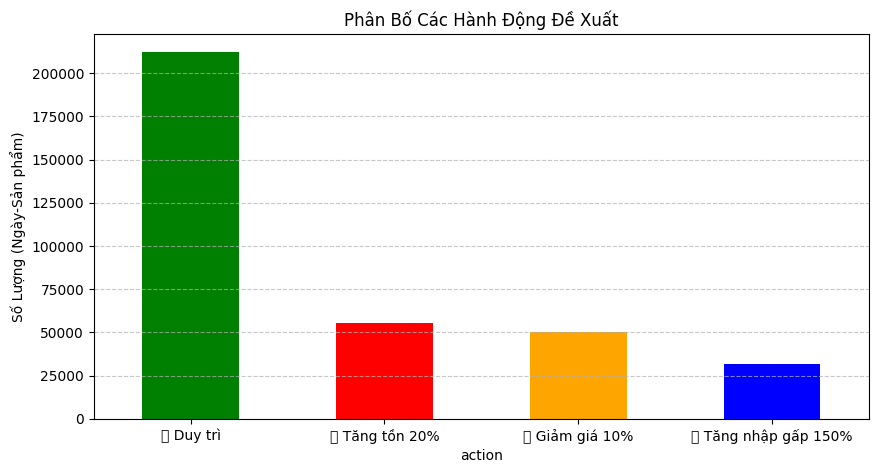

In [ ]:
# --- Biểu đồ Phân bố Hành động ---
plt.figure(figsize=(10, 5))
action_counts.plot(kind='bar', color=['green', 'red', 'orange', 'blue'])
plt.title("Phân Bố Các Hành Động Đề Xuất")
plt.ylabel("Số Lượng (Ngày-Sản phẩm)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

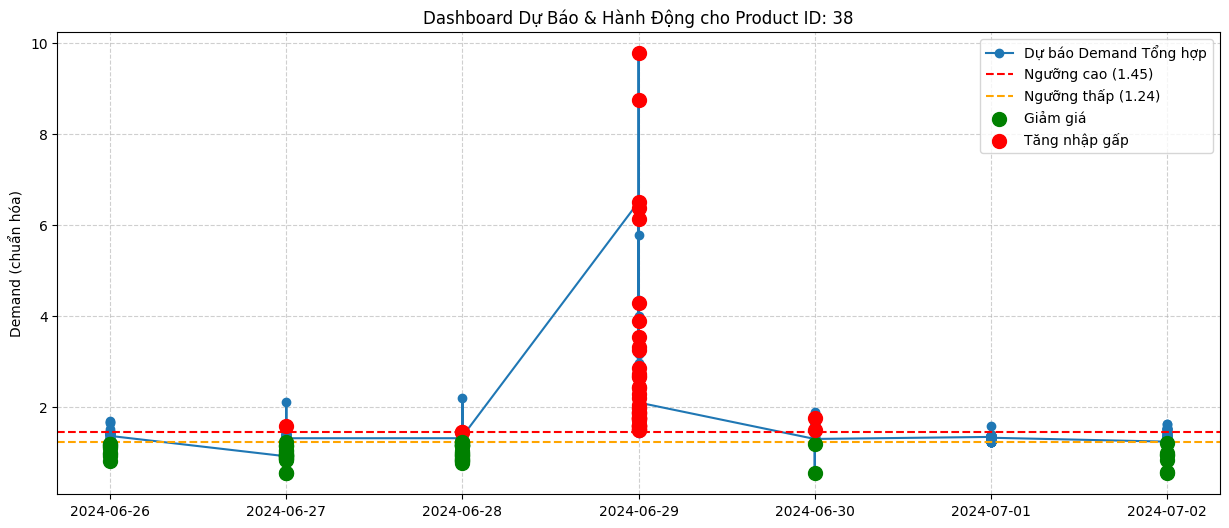

In [ ]:
# --- Biểu đồ Dự báo Demand & Hành động (cho 1 sản phẩm) ---
product_sample = df_new[df_new['product_id'] == df_new['product_id'].iloc[0]].copy()
product_sample = product_sample.sort_values('dt')

plt.figure(figsize=(15, 6))
plt.plot(product_sample['dt'], product_sample['final_demand'], 'o-', label='Dự báo Demand Tổng hợp')
plt.axhline(high_threshold, color='red', linestyle='--', label=f'Ngưỡng cao ({high_threshold:.2f})')
plt.axhline(low_threshold, color='orange', linestyle='--', label=f'Ngưỡng thấp ({low_threshold:.2f})')

for _, row in product_sample.iterrows():
    if '🔥' in row['action']:
        plt.scatter(row['dt'], row['final_demand'], color='red', s=100, zorder=5, label='Tăng nhập gấp')
    elif '📉' in row['action']:
        plt.scatter(row['dt'], row['final_demand'], color='green', s=100, zorder=5, label='Giảm giá')

# Loại bỏ label trùng lặp trong legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title(f"Dashboard Dự Báo & Hành Động cho Product ID: {product_sample['product_id'].iloc[0]}")
plt.ylabel("Demand (chuẩn hóa)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# --- Cell Code Chẩn Đoán Spike Ngày 29/06 ---

print("🚀 Bắt đầu chẩn đoán dữ liệu bất thường ngày 2024-06-29 cho Product ID 38...")

# 1. --- Lọc dữ liệu tại thời điểm xảy ra spike ---
PRODUCT_ID_SPIKE = 38
DATE_SPIKE = '2024-06-29'

df_spike = df_new[
    (df_new['product_id'] == PRODUCT_ID_SPIKE) &
    (df_new['dt'].dt.date == pd.to_datetime(DATE_SPIKE).date())
].copy()

if df_spike.empty:
    print(f"Lỗi: Không tìm thấy dữ liệu cho Product ID {PRODUCT_ID_SPIKE} vào ngày {DATE_SPIKE}.")
else:
    # 2. --- Phân tích thống kê để tìm outlier ---
    print(f"\n=== Thống kê Demand vào ngày {DATE_SPIKE} (cho Product ID {PRODUCT_ID_SPIKE}) ===")
    # Dùng describe() để xem min, max, mean, std...
    print(df_spike['final_demand'].describe())
    print("\n=> NHẬN XÉT: Nếu 'max' lớn hơn 'mean' rất nhiều, đây là dấu hiệu của outlier từ một vài cửa hàng.")

    # 3. --- Xác định các cửa hàng có demand cao nhất ---
    top_5_stores = df_spike.sort_values('final_demand', ascending=False).head(5)
    print(f"\n=== Top 5 Cửa hàng có Demand cao nhất vào ngày {DATE_SPIKE} ===")
    print(top_5_stores[['store_id', 'final_demand', 'daily_latent_demand', 'stock_hour6_22_cnt', 'discount']])

    # 4. --- Mổ xẻ chi tiết cửa hàng có demand cao nhất ---
    highest_demand_store = top_5_stores.iloc[0]
    store_id_highest = int(highest_demand_store['store_id'])
    print(f"\n=== Chi tiết Cửa hàng {store_id_highest} (Demand cao nhất) ===")
    print(f"- Final Demand: {highest_demand_store['final_demand']:.2f}")
    print(f"- Số giờ hết hàng (6h-22h): {int(highest_demand_store['stock_hour6_22_cnt'])}")
    print(f"- Discount: {highest_demand_store['discount']:.2f}")
    print(f"- Nhiệt độ trung bình: {highest_demand_store['avg_temperature']:.1f}°C")
    print("\n--- Pattern Hết Hàng Theo Giờ (0=hết, 1=còn) ---")
    hourly_stock_status = np.array(highest_demand_store['hours_stock_status'])
    print(hourly_stock_status)

    print("\n--- Doanh Số Thực Tế Theo Giờ ---")
    hourly_sales = np.array(highest_demand_store['hours_sale'])
    print(np.round(hourly_sales, 2))

    print("\n=> NHẬN XÉT: Hãy chú ý vào 'Pattern Hết Hàng Theo Giờ'. Nếu có nhiều số 0 ở các giờ cao điểm (khoảng 8-10h và 15-17h), đó chính là nguyên nhân.")

🚀 Bắt đầu chẩn đoán dữ liệu bất thường ngày 2024-06-29 cho Product ID 38...

=== Thống kê Demand vào ngày 2024-06-29 (cho Product ID 38) ===
count    113.000000
mean       2.505525
std        1.293977
min        1.425152
25%        1.984826
50%        2.090734
75%        2.448242
max        9.773539
Name: final_demand, dtype: float64

=> NHẬN XÉT: Nếu 'max' lớn hơn 'mean' rất nhiều, đây là dấu hiệu của outlier từ một vài cửa hàng.

=== Top 5 Cửa hàng có Demand cao nhất vào ngày 2024-06-29 ===
        store_id  final_demand  daily_latent_demand  stock_hour6_22_cnt  \
48576        177      9.773539             9.273539                   9   
26953        134      8.746602             8.246602                  12   
133486       536      6.507068             6.007068                   4   
148088       599      6.371464             5.871464                   8   
169417       806      6.122715             5.622715                  10   

        discount  
48576      0.500  
26953      0.

🚀 Bắt đầu tạo Dashboard cho giai đoạn Lễ 30/4 - 1/5 (ĐÃ SỬA LỖI)...
Đang tải dữ liệu...
✅ Dùng subset: 500000 dòng
Đang phục hồi latent demand cho dữ liệu nguồn...


100%|██████████| 500000/500000 [00:46<00:00, 10659.85it/s]


✅ Đã hoàn thành pipeline trên dữ liệu train.parquet.
✅ Đã lọc được 602 điểm dữ liệu cho Product ID 4 trong giai đoạn lễ.


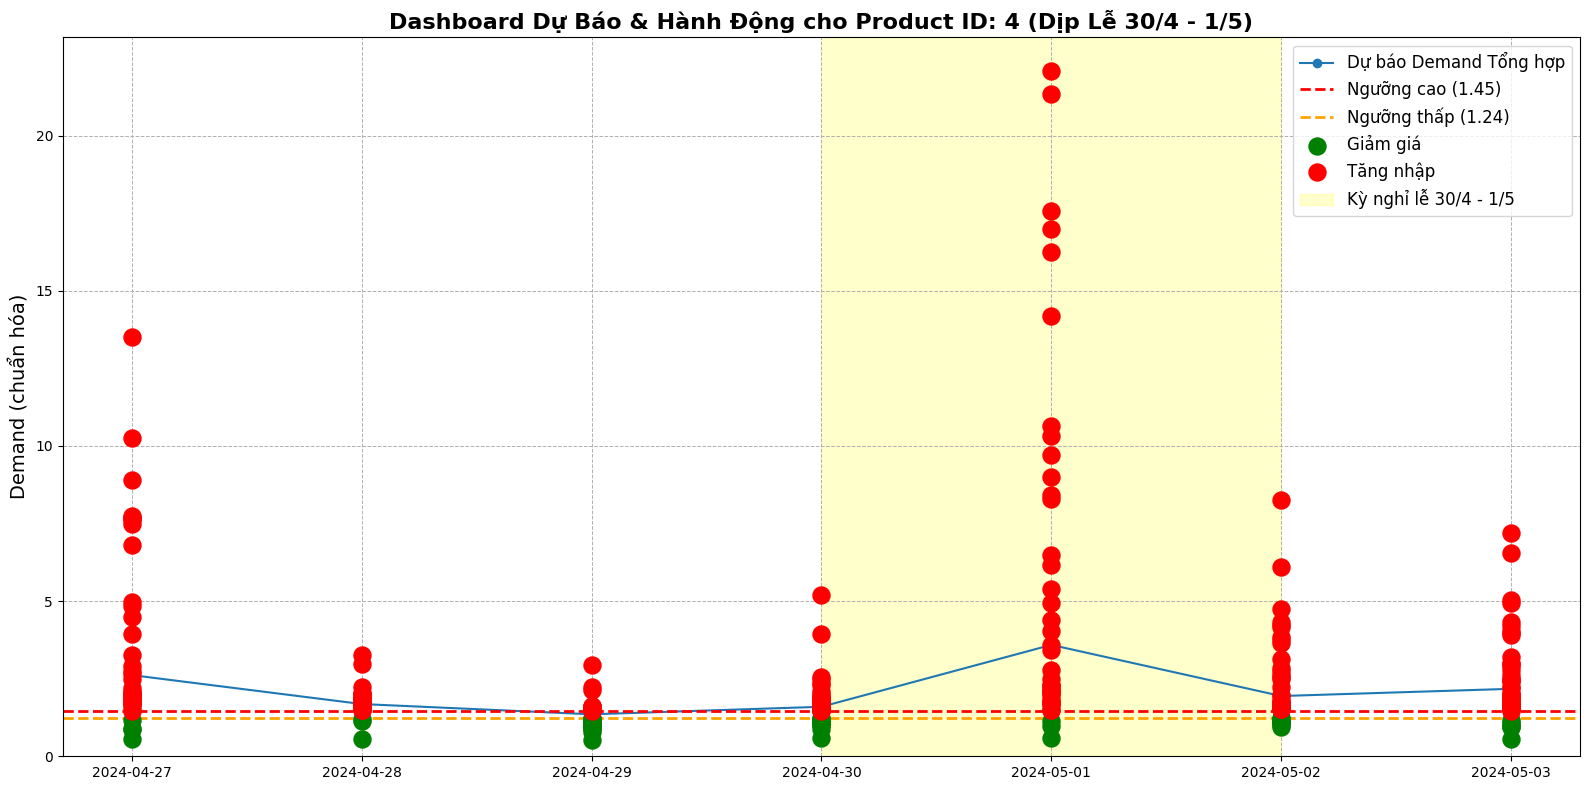

In [ ]:
# --- Cell Sửa Lỗi & Trực Quan Hóa Dashboard Cho Dịp Lễ 30/4 - 1/5 ---

print("🚀 Bắt đầu tạo Dashboard cho giai đoạn Lễ 30/4 - 1/5 (ĐÃ SỬA LỖI)...")

# --- 1. Tải dữ liệu train ---
print("Đang tải dữ liệu...")
df_source = pd.read_parquet(FRESH_DATA_PATH + 'train.parquet')
df_source['dt'] = pd.to_datetime(df_source['dt'])

# Nếu > 1 triệu dòng → dùng 500K để demo
if len(df_source) > 1_000_000:
    df_source = df_source.sample(n=500_000, random_state=42).reset_index(drop=True)
    print(f"✅ Dùng subset: {len(df_source)} dòng")
else:
    print(f"✅ Dùng toàn bộ: {len(df_source)} dòng")

# Chạy lại pipeline inference trên bộ dữ liệu nguồn này
print("Đang phục hồi latent demand cho dữ liệu nguồn...")
X_source = np.array([prepare_data(row) for _, row in tqdm(df_source.iterrows(), total=len(df_source))])
X_source_scaled = scaler_X.transform(X_source)

with torch.no_grad():
    Y_pred_source = model(torch.tensor(X_source_scaled, dtype=torch.float32)).numpy()
Y_pred_source = np.maximum(Y_pred_source, 0)

df_source['daily_latent_demand'] = Y_pred_source[:, 6:23].sum(axis=1)

# Áp dụng Lịch ngày lễ và demand khách sỉ
df_source['holiday_name'] = df_source['dt'].map(holiday_df.set_index('date')['holiday_name']).fillna('None')
df_source['adjusted_demand'] = df_source.apply(
    lambda row: row['daily_latent_demand'] * holiday_multipliers.get(row['holiday_name'], 1.0), axis=1
)
df_source['final_demand'] = df_source['adjusted_demand'] + normalized_wholesale_demand
df_source['action'] = df_source.apply(get_action, axis=1)
print("✅ Đã hoàn thành pipeline trên dữ liệu train.parquet.")

# 3. --- CHUẨN BỊ DỮ LIỆU ĐỂ VẼ BIỂU ĐỒ ---
PRODUCT_ID_FOCUS = 4
start_date = '2024-04-27'
end_date = '2024-05-03'
holiday_start = '2024-04-30'
holiday_end = '2024-05-01'

df_focus = df_source[
    (df_source['product_id'] == PRODUCT_ID_FOCUS) &
    (df_source['dt'] >= start_date) &
    (df_source['dt'] <= end_date)
].copy()

daily_mean_demand = df_focus.groupby('dt')['final_demand'].mean()

print(f"✅ Đã lọc được {len(df_focus)} điểm dữ liệu cho Product ID {PRODUCT_ID_FOCUS} trong giai đoạn lễ.")


# 4. --- VẼ LẠI BIỂU ĐỒ (ĐÃ SỬA FONT VÀ DỮ LIỆU) ---
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(daily_mean_demand.index, daily_mean_demand.values, 'o-', label='Dự báo Demand Tổng hợp')
ax.axhline(high_threshold, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng cao ({high_threshold:.2f})')
ax.axhline(low_threshold, color='orange', linestyle='--', linewidth=2, label=f'Ngưỡng thấp ({low_threshold:.2f})')

action_colors = {
    '📉 Giảm giá 10%': 'green',
    '🔥 Tăng nhập gấp 150%': 'red'
}

for action, color in action_colors.items():
    subset = df_focus[df_focus['action'] == action]
    if not subset.empty:
        # Lấy tên ngắn gọn cho legend
        label_name = ' '.join(action.split(' ')[1:3])
        ax.scatter(subset['dt'], subset['final_demand'], color=color, s=150, zorder=5, label=label_name)

ax.axvspan(pd.to_datetime(holiday_start), pd.to_datetime(holiday_end) + pd.Timedelta(days=1),
           color='yellow', alpha=0.2, label='Kỳ nghỉ lễ 30/4 - 1/5')

ax.set_title(f'Dashboard Dự Báo & Hành Động cho Product ID: {PRODUCT_ID_FOCUS} (Dịp Lễ 30/4 - 1/5)', fontsize=16, fontfamily='Noto Sans', fontweight='bold')
ax.set_ylabel('Demand (chuẩn hóa)', fontsize=14, fontfamily='Noto Sans')
ax.set_ylim(bottom=0)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# --- Bảng Kế hoạch Hành động ---
action_plan = df_new[df_new['action'] != '✅ Duy trì'].copy()
action_plan = action_plan.sort_values(['dt', 'final_demand'], ascending=[True, False])
print("\n=== Bảng Kế Hoạch Hành Động (Top 10) ===")
print(action_plan[['dt', 'product_id', 'store_id', 'final_demand', 'action']].head(10).to_string(index=False))


=== Bảng Kế Hoạch Hành Động (Top 10) ===
        dt  product_id  store_id  final_demand         action
2024-06-26         267       475     25.368427 📈 Tăng tồn 20%
2024-06-26         267       334     25.119919 📈 Tăng tồn 20%
2024-06-26         267       409     25.032806 📈 Tăng tồn 20%
2024-06-26         267        50     23.050764 📈 Tăng tồn 20%
2024-06-26         589       645     22.113480 📈 Tăng tồn 20%
2024-06-26         267        87     21.837019 📈 Tăng tồn 20%
2024-06-26         267        11     20.416971 📈 Tăng tồn 20%
2024-06-26         267       853     20.109138 📈 Tăng tồn 20%
2024-06-26         267        94     19.576488 📈 Tăng tồn 20%
2024-06-26         267       440     19.513872 📈 Tăng tồn 20%


## ✅ Kết luận

Hệ thống **RetailDemand Copilot** đã tích hợp thành công dữ liệu từ nhiều nguồn để đưa ra đề xuất hành động thông minh, giúp các nhà bán lẻ SME tại Việt Nam:
- **Giảm stockout** nhờ phục hồi latent demand và dự báo chính xác hơn.
- **Tối ưu tồn kho** cho khách sỉ B2B.
- **Chuẩn bị tốt hơn cho các dịp lễ, Tết**.
- **Ra quyết định nhanh chóng** dựa trên dashboard trực quan.

In [14]:
# --- Cell Code để tạo file demo.parquet ---

print("🚀 Bắt đầu tạo 'Golden Demo Set'...")

# 1. Tải bộ train gốc
df_train_source = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/train.parquet")
df_train_source['dt'] = pd.to_datetime(df_train_source['dt'])

# 2. Định nghĩa các kịch bản cần lấy
holiday_dates = pd.to_datetime(['2024-04-30', '2024-05-01'])
high_stockout_dates = pd.to_datetime(['2024-06-15', '2024-06-20'])
normal_dates = pd.to_datetime(['2024-05-15', '2024-05-20', '2024-05-25'])

# 3. Trích xuất dữ liệu cho từng kịch bản (lấy 100 dòng cho mỗi kịch bản để đa dạng)
df_holidays = df_train_source[df_train_source['dt'].isin(holiday_dates)].sample(n=100, random_state=42)
df_high_stockout = df_train_source[
    df_train_source['dt'].isin(high_stockout_dates) &
    (df_train_source['stock_hour6_22_cnt'] > 10)
].sample(n=100, random_state=42)
df_normal = df_train_source[df_train_source['dt'].isin(normal_dates)].sample(n=100, random_state=42)

# 4. Gộp lại thành bộ demo cuối cùng
df_demo = pd.concat([df_holidays, df_high_stockout, df_normal]).reset_index(drop=True)
df_demo = df_demo.sort_values('dt')

# 5. Lưu file
demo_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/demo.parquet"
df_demo.to_parquet(demo_path)

print(f"✅ Đã tạo thành công file 'demo.parquet' với {len(df_demo)} dòng.")
print(f"File được lưu tại: {demo_path}")
print("\nCác ngày có trong bộ demo:")
print(df_demo['dt'].dt.date.unique())

🚀 Bắt đầu tạo 'Golden Demo Set'...
✅ Đã tạo thành công file 'demo.parquet' với 300 dòng.
File được lưu tại: /content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/demo.parquet

Các ngày có trong bộ demo:
[datetime.date(2024, 4, 30) datetime.date(2024, 5, 1)
 datetime.date(2024, 5, 15) datetime.date(2024, 5, 20)
 datetime.date(2024, 5, 25) datetime.date(2024, 6, 15)
 datetime.date(2024, 6, 20)]


🚀 Bắt đầu tạo Dashboard nâng cao (Phiên bản cuối cùng)...
✅ Đã lọc và xử lý dữ liệu cho Product ID 666. Tìm thấy 2 ngày có dữ liệu.


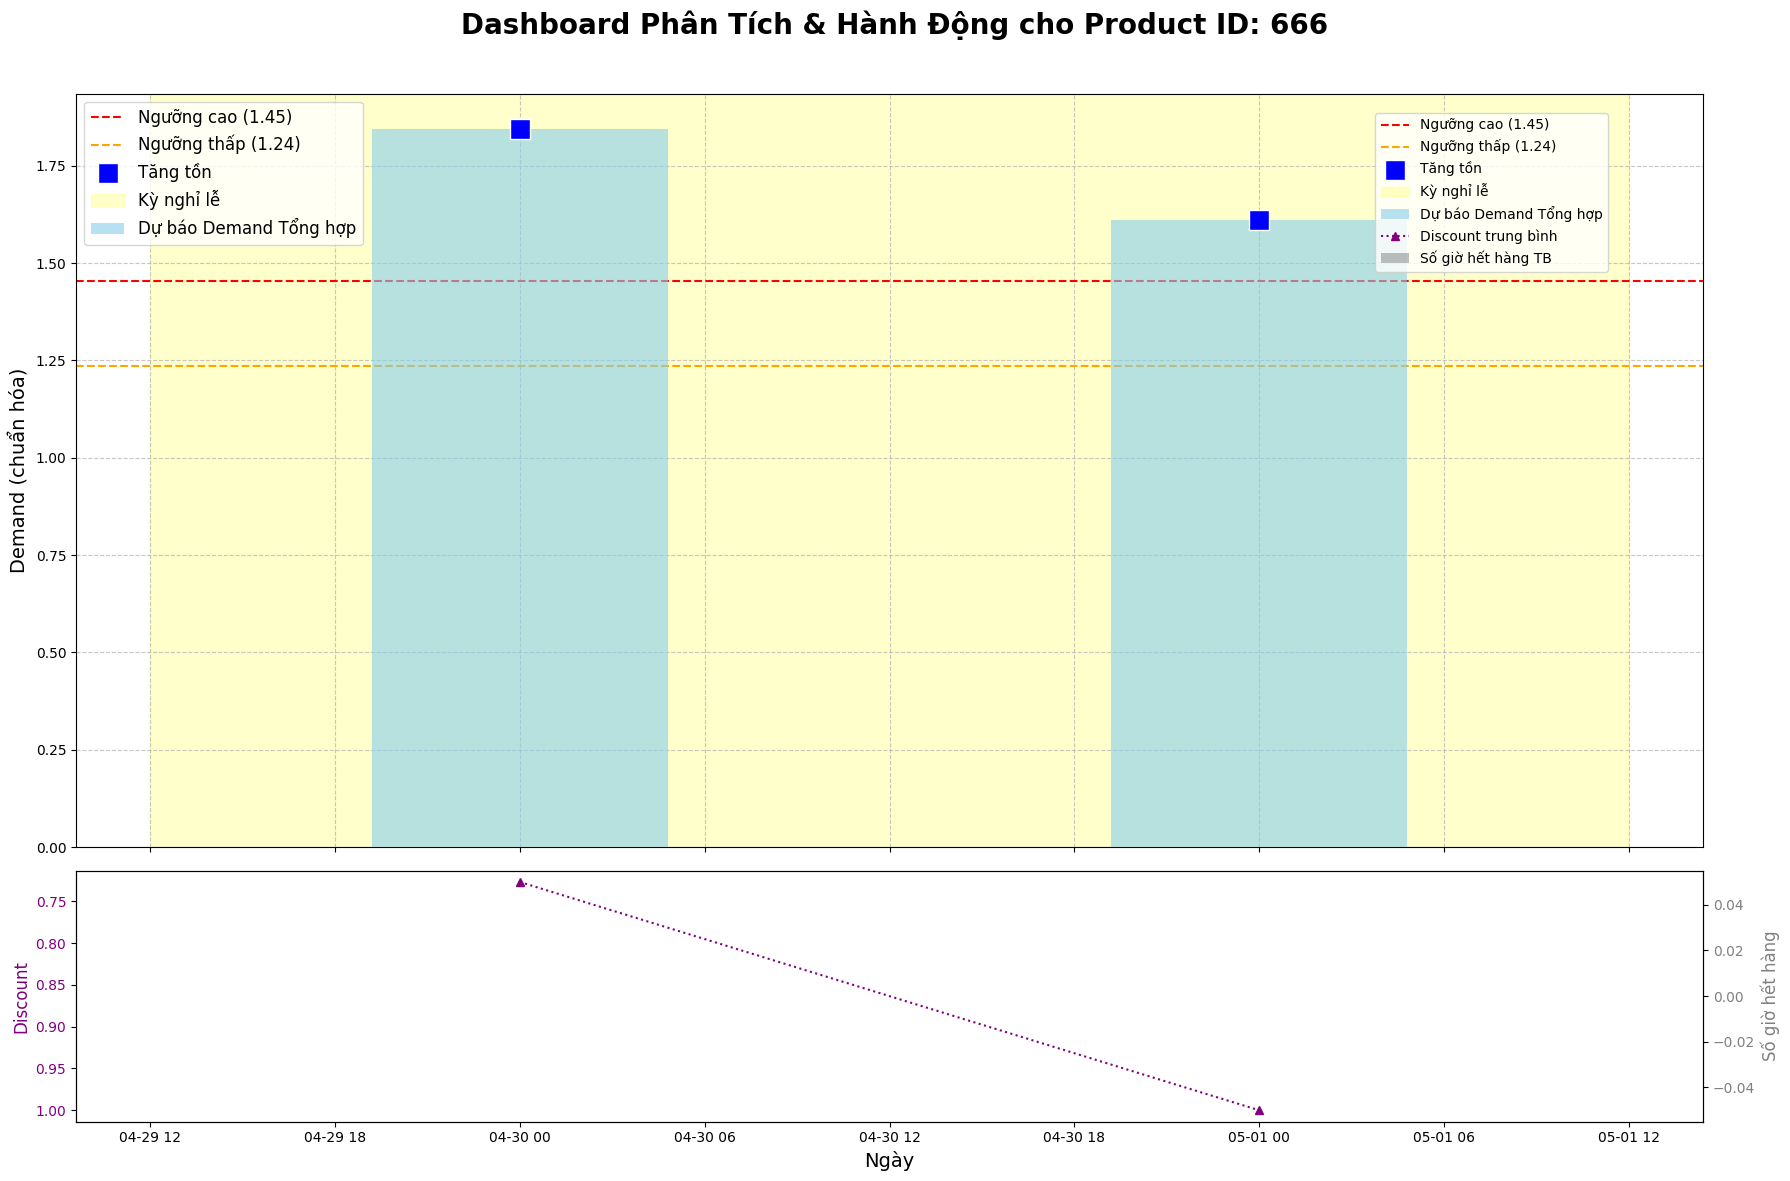

\n=== Bảng Kế Hoạch Hành Động (Ví dụ) ===
        dt  product_id               action  final_demand  discount  stock_hour6_22_cnt
2024-04-30         666       📈 Tăng tồn 20%      1.843253     0.727                   0
2024-04-30         531       📈 Tăng tồn 20%      1.990738     0.743                   3
2024-04-30         144       📈 Tăng tồn 20%      1.457137     1.000                   0
2024-04-30         486       📈 Tăng tồn 20%      1.918486     0.675                   0
2024-04-30         351       📈 Tăng tồn 20%      1.457137     1.000                   0
2024-04-30         285 🔥 Tăng nhập gấp 150%      1.783550     1.000                   4
2024-04-30         292       📈 Tăng tồn 20%      1.457137     0.869                   0
2024-04-30         858       📉 Giảm giá 10%      0.868979     1.000                  15
2024-04-30         310       📈 Tăng tồn 20%      1.457137     1.000                   0
2024-04-30         194       📈 Tăng tồn 20%      1.500199     1.000           

In [22]:
# --- Cell Code Cập Nhật Cuối Cùng: Dashboard Linh Hoạt Hơn ---

print("🚀 Bắt đầu tạo Dashboard nâng cao (Phiên bản cuối cùng)...")

# --- Chuẩn bị dữ liệu cho biểu đồ ---
# Tự động chọn một sản phẩm có trong ngày lễ để demo
product_ids_in_holiday = df_demo[df_demo['holiday_name'] != 'None']['product_id'].unique()
if len(product_ids_in_holiday) > 0:
    PRODUCT_ID_DEMO = product_ids_in_holiday[0]
else:
    PRODUCT_ID_DEMO = df_demo['product_id'].iloc[0] # Fallback

df_focus = df_demo[df_demo['product_id'] == PRODUCT_ID_DEMO].copy()

# Nhóm theo ngày để lấy giá trị trung bình
daily_summary = df_focus.groupby('dt').agg(
    final_demand=('final_demand', 'mean'),
    avg_discount=('discount', 'mean'),
    avg_stockout_hours=('stock_hour6_22_cnt', 'mean')
).reset_index()

print(f"✅ Đã lọc và xử lý dữ liệu cho Product ID {PRODUCT_ID_DEMO}. Tìm thấy {len(daily_summary)} ngày có dữ liệu.")


# --- Bắt đầu vẽ ---
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(18, 12),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)
fig.suptitle(f'Dashboard Phân Tích & Hành Động cho Product ID: {PRODUCT_ID_DEMO}', fontsize=20, fontweight='bold')

# --- Biểu đồ 1: Demand & Hành động ---
# CẬP NHẬT: Dùng bar chart thay vì line plot để hiển thị khi có ít điểm
ax1.bar(daily_summary['dt'], daily_summary['final_demand'], label='Dự báo Demand Tổng hợp', zorder=5, color='skyblue', alpha=0.6, width=0.4)

ax1.axhline(high_threshold, color='red', linestyle='--', label=f'Ngưỡng cao ({high_threshold:.2f})')
ax1.axhline(low_threshold, color='orange', linestyle='--', label=f'Ngưỡng thấp ({low_threshold:.2f})')

action_map = {
    '📉 Giảm giá 10%': ('green', 'Giảm giá', 'v'),
    '🔥 Tăng nhập gấp 150%': ('red', 'Tăng nhập gấp', 'o'),
    '📈 Tăng tồn 20%': ('blue', 'Tăng tồn', 's')
}

for action_str, (color, label, marker) in action_map.items():
    subset = df_focus[df_focus['action'] == action_str]
    if not subset.empty:
        ax1.scatter(subset['dt'], subset['final_demand'], color=color, s=200, zorder=15, label=label, edgecolors='white', marker=marker)

# Highlight ngày lễ
holiday_dates_in_focus = df_focus[df_focus['holiday_name'] != 'None']['dt'].unique()
if len(holiday_dates_in_focus) > 0:
    ax1.axvspan(min(holiday_dates_in_focus) - pd.Timedelta(hours=12), max(holiday_dates_in_focus) + pd.Timedelta(hours=12), color='yellow', alpha=0.2, label='Kỳ nghỉ lễ')

ax1.set_ylabel('Demand (chuẩn hóa)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), fontsize=12, loc='upper left')

# --- Biểu đồ 2: Ngữ cảnh (Discount & Stockout) ---
ax2.plot(daily_summary['dt'], daily_summary['avg_discount'], color='purple', linestyle=':', marker='^', label='Discount trung bình')
ax2.set_ylabel('Discount', color='purple', fontsize=12)
ax2.tick_params(axis='y', labelcolor='purple')
ax2.invert_yaxis()

ax2b = ax2.twinx()
ax2b.bar(daily_summary['dt'], daily_summary['avg_stockout_hours'], color='gray', alpha=0.5, width=0.4, label='Số giờ hết hàng TB')
ax2b.set_ylabel('Số giờ hết hàng', color='gray', fontsize=12)
ax2b.tick_params(axis='y', labelcolor='gray')

ax2.set_xlabel('Ngày', fontsize=14)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- In ra bảng kế hoạch hành động ---
print("\\n=== Bảng Kế Hoạch Hành Động (Ví dụ) ===")
print(df_demo[df_demo['action'] != '✅ Duy trì'][['dt', 'product_id', 'action', 'final_demand', 'discount', 'stock_hour6_22_cnt']].head(10).to_string(index=False))